# 09-01 Univariate Analysis

Dieses Notebook analysiert den finalen Datensatz `23_cleaned_master_data.pkl` univariat. Die Spalten werden zuerst nach inhaltlichen Rollen getrennt, weil nicht jede Spalte dieselben statistischen Kennzahlen sinnvoll zulässt: kontinuierliche Features brauchen Verteilungsmaße, kategoriale Features Häufigkeiten, IDs Eindeutigkeitsprüfungen und Zeit-/Geo-Spalten eigene Plausibilitätschecks.

In [93]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 180)

DATA_PATH = Path("../../data/processed/24_cleaned_master_data.pkl")
print(f"Data path: {DATA_PATH.resolve()}")


Data path: /Users/roberthendrich/GADA-Group3-Cycling-Stage-Prediction/data/processed/24_cleaned_master_data.pkl


## Daten laden

Der finale Pickle lässt sich in der aktuellen Projektumgebung direkt mit `pd.read_pickle` laden. Die kategorialen Spalten `team_tier` und `won_how_cat` bleiben dabei als `category` erhalten.


In [94]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. Run this notebook from src/Notebooks or adjust DATA_PATH."
    )

df = pd.read_pickle(DATA_PATH)

print(f"Shape: {df.shape[0]:,} Zeilen x {df.shape[1]} Spalten")
print("\nDatentypen vor lokaler Analyse-Konvertierung:")
display(df.dtypes.value_counts().to_frame("n_columns"))
display(df.head(3))


Shape: 196,048 Zeilen x 42 Spalten

Datentypen vor lokaler Analyse-Konvertierung:


,n_columns
object,15
float64,15
int64,3
Int64,3
Float64,3
datetime64[ns],1
category,1
category,1


,meta_race,meta_year,meta_url,rank,meta_rider_url,height,meta_name,meta_nationality,weight,meta_url_name,meta_departure,meta_arrival,distance,vertical_meters,one_day_races,gc,time_trial,sprint,climber,hills,stage_nr,meta_date,meta_departure_lat,meta_departure_lon,meta_arrival_lat,meta_arrival_lon,rider_points_season,rider_rank_season,meta_current_team,team_tier,age_at_race,rider_bmi,race_competitiveness_median,team_power_index,wind_stability_index,weather_temp_mean,weather_temp_trend,weather_rain_prob_mean,weather_precipitation_mean,weather_humidity_mean,won_how_cat,gradient_final_km
0,tour-de-france,2005,https://www.procyclingstats.com/race/tour-de-f...,1.0,tom-boonen,1.92,Tom Boonen,BE,82,tom-boonen,Challans,Les Essarts,182.0,432,10498.0,1765.0,1146.0,8626.0,136.0,2296.0,2,2005-07-03,46.847809,-1.877431,46.779115,-1.242859,2149.0,2,Quickstep - Innergetic,elite,24,22.243924,219.0,345.0,0.238106,26.07,4.5,0.025,0.025,59.5,sprint_large_group,0.5
1,tour-de-france,2005,https://www.procyclingstats.com/race/tour-de-f...,2.0,thor-hushovd,1.83,Thor Hushovd,NO,83,thor-hushovd,Challans,Les Essarts,182.0,432,4271.0,1237.0,2039.0,5394.0,982.0,3042.0,2,2005-07-03,46.847809,-1.877431,46.779115,-1.242859,1265.0,9,Crédit Agricole,elite,27,24.784258,219.0,119.0,0.238106,26.07,4.5,0.025,0.025,59.5,sprint_large_group,0.5
2,tour-de-france,2005,https://www.procyclingstats.com/race/tour-de-f...,3.0,robbie-mcewen,1.71,Robbie McEwen,AU,67,robbie-mcewen,Challans,Les Essarts,182.0,432,4996.0,1461.0,109.0,10554.0,640.0,2650.0,2,2005-07-03,46.847809,-1.877431,46.779115,-1.242859,1444.0,6,Davitamon - Lotto,elite,33,22.913033,219.0,195.0,0.238106,26.07,4.5,0.025,0.025,59.5,sprint_large_group,0.5


## Wetterspalten: `object` zu numerisch

Die Wetterspalten liegen im 23er Datensatz nicht als Kategorien vor, sondern als `object`-Spalten mit numerischen Werten. Für Kennzahlen, Boxplots und Histogramme werden sie im Notebook lokal mit `pd.to_numeric` in numerische Spalten überführt; der Pickle wird dabei nicht verändert.


In [95]:
WEATHER_NUMERIC_COLS = [
    "wind_stability_index",
    "weather_temp_mean",
    "weather_temp_trend",
    "weather_rain_prob_mean",
    "weather_precipitation_mean",
    "weather_humidity_mean",
]

coercion_rows = []
for col in [c for c in WEATHER_NUMERIC_COLS if c in df.columns]:
    before_dtype = df[col].dtype
    missing_before = int(df[col].isna().sum())
    converted = pd.to_numeric(df[col], errors="coerce")
    missing_after = int(converted.isna().sum())
    df[col] = converted
    coercion_rows.append(
        {
            "column": col,
            "dtype_before": str(before_dtype),
            "dtype_after": str(df[col].dtype),
            "new_missing_from_conversion": missing_after - missing_before,
        }
    )

coercion_report = pd.DataFrame(coercion_rows)
display(coercion_report)

print("\nDatentypen nach lokaler Analyse-Konvertierung:")
display(df.dtypes.value_counts().to_frame("n_columns"))

,column,dtype_before,dtype_after,new_missing_from_conversion
0,wind_stability_index,object,float64,0
1,weather_temp_mean,object,float64,0
2,weather_temp_trend,object,float64,0
3,weather_rain_prob_mean,object,float64,0
4,weather_precipitation_mean,object,float64,0
5,weather_humidity_mean,object,float64,0



Datentypen nach lokaler Analyse-Konvertierung:


,n_columns
float64,21
object,9
int64,3
Int64,3
Float64,3
datetime64[ns],1
category,1
category,1


## Spaltenrollen

Die Rollen orientieren sich am Informationsgehalt der Spalten.

In [96]:
def _filter_existing(cols: list[str], frame: pd.DataFrame = df) -> list[str]:
    return [c for c in cols if c in frame.columns]


target = _filter_existing(["rank"])

id_like = _filter_existing([
    "meta_url",
    "meta_rider_url",
    "meta_url_name",
    "meta_name",
])

temporal = _filter_existing(["meta_date"])

geo = _filter_existing([
    "meta_departure_lat",
    "meta_departure_lon",
    "meta_arrival_lat",
    "meta_arrival_lon",
])

ordinal_discrete = _filter_existing([
    "meta_year",
    "stage_nr",
    "rider_rank_season",
])

categorical_low = _filter_existing([
    "meta_race",
    "meta_nationality",
    "team_tier",
    "won_how_cat",
])

categorical_high = _filter_existing([
    "meta_departure",
    "meta_arrival",
    "meta_current_team",
])


race_profile = _filter_existing([
    "distance",
    "vertical_meters",
    "gradient_final_km",
    "race_competitiveness_median",
])

rider_profile = _filter_existing([
    "height",
    "weight",
    "age_at_race",
    "rider_bmi",
])

performance_scores = _filter_existing([
    "one_day_races",
    "gc",
    "time_trial",
    "sprint",
    "climber",
    "hills",
    "rider_points_season",
    "team_power_index",
])

weather_features = _filter_existing(WEATHER_NUMERIC_COLS)

continuous_features = race_profile + rider_profile + performance_scores + weather_features
categorical_features = categorical_low + categorical_high 

role_groups = {
    "target": target,
    "id_like": id_like,
    "temporal": temporal,
    "geo": geo,
    "ordinal_discrete": ordinal_discrete,
    "categorical_low": categorical_low,
    "categorical_high": categorical_high,
    "race_profile_continuous": race_profile,
    "rider_profile_continuous": rider_profile,
    "performance_scores_continuous": performance_scores,
    "weather_continuous": weather_features,
}

role_overview = pd.DataFrame(
    [
        {
            "role": role,
            "n_columns": len(cols),
            "columns": ", ".join(cols) if cols else "-",
        }
        for role, cols in role_groups.items()
    ]
)
display(role_overview)

assigned = [col for cols in role_groups.values() for col in cols]
assignment_counts = pd.Series(assigned).value_counts()
duplicate_assignments = assignment_counts[assignment_counts > 1].index.tolist()
unassigned_cols = sorted(set(df.columns) - set(assigned))

print(f"Zugewiesene Spalten: {len(set(assigned))} von {df.shape[1]}")
print(f"Mehrfach zugewiesen: {duplicate_assignments if duplicate_assignments else 'keine'}")
print(f"Nicht zugewiesen: {unassigned_cols if unassigned_cols else 'keine'}")

assert not duplicate_assignments, f"Spalten mehrfach zugewiesen: {duplicate_assignments}"
assert not unassigned_cols, f"Spalten ohne Rolle: {unassigned_cols}"

,role,n_columns,columns
0,target,1,rank
1,id_like,4,"meta_url, meta_rider_url, meta_url_name, meta_..."
2,temporal,1,meta_date
3,geo,4,"meta_departure_lat, meta_departure_lon, meta_a..."
4,ordinal_discrete,3,"meta_year, stage_nr, rider_rank_season"
5,categorical_low,4,"meta_race, meta_nationality, team_tier, won_ho..."
6,categorical_high,3,"meta_departure, meta_arrival, meta_current_team"
7,race_profile_continuous,4,"distance, vertical_meters, gradient_final_km, ..."
8,rider_profile_continuous,4,"height, weight, age_at_race, rider_bmi"
9,performance_scores_continuous,8,"one_day_races, gc, time_trial, sprint, climber..."


Zugewiesene Spalten: 42 von 42
Mehrfach zugewiesen: keine
Nicht zugewiesen: keine


## Welche Kennzahlen für welche Spalten?

| Rolle | Sinnvolle Kennzahlen |
|---|---|
| Kontinuierlich numerisch | `count`, Missing-Anteil, Mittelwert, Standardabweichung, Varianz, Min/Max, Quartile, Median, IQR, Skewness, Kurtosis, Modus |
| Ordinal / diskret | `count`, Missing-Anteil, Min/Max, Quartile, Median, Modus, Anzahl Ausprägungen |
| Kategorial | Missing-Anteil, Anzahl Kategorien, Modus, Modus-Häufigkeit, Top-Ausprägungen |
| IDs / Namen / URLs | Eindeutigkeit, Duplikate, Missing-Anteil |
| Datum | Min/Max-Datum, Zeitraum in Tagen, Missing-Anteil |
| Koordinaten | Min/Max/Mittelwert und Missing-Anteil als Plausibilitätscheck |

## Univariate Statistik-Tabellen

In [97]:
def numeric_summary(frame: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    n_total = len(frame)
    for col in cols:
        s = pd.to_numeric(frame[col], errors="coerce")
        s_clean = s.dropna().astype(float)
        n_missing = int(s.isna().sum())
        if s_clean.empty:
            rows.append({"column": col, "count": 0, "n_missing": n_missing, "missing_pct": 100.0})
            continue
        q1, median, q3 = np.percentile(s_clean, [25, 50, 75])
        mode_vals = s_clean.mode()
        rows.append(
            {
                "column": col,
                "count": int(s_clean.shape[0]),
                "n_missing": n_missing,
                "missing_pct": round(100 * n_missing / n_total, 2),
                "mean": s_clean.mean(),
                "std": s_clean.std(),
                "var": s_clean.var(),
                "min": s_clean.min(),
                "q1": q1,
                "median": median,
                "q3": q3,
                "max": s_clean.max(),
                "iqr": q3 - q1,
                "skew": s_clean.skew(),
                "kurtosis": s_clean.kurt(),
                "mode": mode_vals.iloc[0] if not mode_vals.empty else np.nan,
                "n_unique": int(s_clean.nunique()),
            }
        )
    return pd.DataFrame(rows).set_index("column") if rows else pd.DataFrame()


continuous_stats = numeric_summary(df, continuous_features).round(3)
continuous_stats

,count,n_missing,missing_pct,mean,std,var,min,q1,median,q3,max,iqr,skew,kurtosis,mode,n_unique
column,,,,,,,,,,,,,,,,
distance,196048,0,0.00,180.295,29.118,847.879,59.500,163.500,181.000,199.000,264.000,35.500,-0.339,0.757,177.000,463
vertical_meters,196048,0,0.00,2651.735,1303.831,1699975.949,122.000,1651.000,2570.000,3623.000,6939.000,1972.000,0.268,-0.577,726.000,1024
gradient_final_km,192030,4018,2.05,2.867,3.349,11.214,0.000,0.200,1.400,4.900,14.400,4.700,1.199,0.582,0.000,126
race_competitiveness_median,196048,0,0.00,302.735,82.185,6754.369,148.000,217.500,327.500,371.500,459.000,154.000,-0.345,-1.173,373.000,288
height,196048,0,0.00,1.801,0.064,0.004,1.590,1.750,1.800,1.840,2.040,0.090,0.007,-0.084,1.800,41
weight,196048,0,0.00,68.182,6.383,40.747,48.000,63.000,68.000,72.000,94.000,9.000,0.237,-0.073,70.000,43
age_at_race,196048,0,0.00,28.537,4.122,16.989,18.000,25.000,28.000,31.000,42.000,6.000,0.350,-0.500,27.000,25
rider_bmi,196048,0,0.00,20.991,1.311,1.718,16.245,20.069,20.911,21.798,26.754,1.729,0.389,0.495,21.605,508
one_day_races,196048,0,0.00,1261.948,1739.817,3026962.789,0.000,293.000,664.000,1501.000,15708.000,1208.000,3.461,16.164,248.000,1139


In [98]:
def ordinal_summary(frame: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    n_total = len(frame)
    for col in cols:
        s = pd.to_numeric(frame[col], errors="coerce")
        s_clean = s.dropna()
        n_missing = int(s.isna().sum())
        if s_clean.empty:
            rows.append({"column": col, "count": 0, "n_missing": n_missing, "missing_pct": 100.0})
            continue
        q1, median, q3 = np.percentile(s_clean, [25, 50, 75])
        mode_vals = s_clean.mode()
        rows.append(
            {
                "column": col,
                "count": int(s_clean.shape[0]),
                "n_missing": n_missing,
                "missing_pct": round(100 * n_missing / n_total, 2),
                "min": s_clean.min(),
                "q1": q1,
                "median": median,
                "q3": q3,
                "max": s_clean.max(),
                "mode": mode_vals.iloc[0] if not mode_vals.empty else np.nan,
                "n_unique": int(s_clean.nunique()),
            }
        )
    return pd.DataFrame(rows).set_index("column") if rows else pd.DataFrame()


ordinal_stats = ordinal_summary(df, ordinal_discrete).round(3)
ordinal_stats

,count,n_missing,missing_pct,min,q1,median,q3,max,mode,n_unique
column,,,,,,,,,,
meta_year,196048,0,0.0,2005,2010.0,2015.0,2020.0,2025,2017,21
stage_nr,196048,0,0.0,1,6.0,10.0,15.0,21,3,21
rider_rank_season,196048,0,0.0,1,118.0,294.0,564.0,9999,21,1310


In [99]:
def categorical_summary(frame: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    n_total = len(frame)
    for col in cols:
        s = frame[col].astype("object")
        n_missing = int(s.isna().sum())
        s_clean = s.dropna()
        if s_clean.empty:
            rows.append({"column": col, "count": 0, "n_missing": n_missing, "missing_pct": 100.0})
            continue
        vc = s_clean.value_counts()
        mode_val = vc.index[0]
        mode_freq = int(vc.iloc[0])
        top5 = ", ".join(f"{idx} ({cnt:,})" for idx, cnt in vc.head(5).items())
        rows.append(
            {
                "column": col,
                "count": int(s_clean.shape[0]),
                "n_missing": n_missing,
                "missing_pct": round(100 * n_missing / n_total, 2),
                "n_unique": int(s_clean.nunique()),
                "mode": mode_val,
                "mode_freq": mode_freq,
                "mode_share_pct": round(100 * mode_freq / s_clean.shape[0], 2),
                "top5": top5,
            }
        )
    return pd.DataFrame(rows).set_index("column") if rows else pd.DataFrame()


cat_stats = categorical_summary(df, categorical_features)
cat_stats

,count,n_missing,missing_pct,n_unique,mode,mode_freq,mode_share_pct,top5
column,,,,,,,,
meta_race,196048,0,0.00,3,tour-de-france,67311,34.33,"tour-de-france (67,311), vuelta-a-espana (64,4..."
meta_nationality,196048,0,0.00,62,IT,29751,15.18,"IT (29,751), FR (27,287), ES (26,380), BE (15,..."
team_tier,196048,0,0.00,3,elite,161633,82.45,"elite (161,633), continental (34,377), other (38)"
won_how_cat,195274,774,0.39,5,solo_or_attack,77264,39.57,"solo_or_attack (77,264), sprint_large_group (6..."
meta_departure,196048,0,0.00,864,Pau,2475,1.26,"Pau (2,475), Albertville (1,141), Modena (1,06..."
meta_arrival,196048,0,0.00,838,Paris,2655,1.35,"Paris (2,655), Madrid (2,328), Lagos de Covado..."
meta_current_team,196048,0,0.00,243,Movistar Team,6617,3.38,"Movistar Team (6,617), AG2R La Mondiale (5,787..."


In [100]:
def id_summary(frame: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in cols:
        s = frame[col]
        s_clean = s.dropna()
        n_unique = int(s_clean.nunique())
        rows.append(
            {
                "column": col,
                "count": int(s_clean.shape[0]),
                "n_missing": int(s.isna().sum()),
                "n_unique": n_unique,
                "n_duplicates": int(s_clean.shape[0] - n_unique),
                "uniqueness_pct": round(100 * n_unique / max(s_clean.shape[0], 1), 2),
            }
        )
    return pd.DataFrame(rows).set_index("column") if rows else pd.DataFrame()


id_stats = id_summary(df, id_like)
id_stats

,count,n_missing,n_unique,n_duplicates,uniqueness_pct
column,,,,,
meta_url,196048,0,1166,194882,0.59
meta_rider_url,196048,0,1996,194052,1.02
meta_url_name,196048,0,1996,194052,1.02
meta_name,196048,0,1996,194052,1.02


In [101]:
def temporal_summary(frame: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    n_total = len(frame)
    for col in cols:
        s = pd.to_datetime(frame[col], errors="coerce")
        s_clean = s.dropna()
        if s_clean.empty:
            rows.append({"column": col, "count": 0, "n_missing": int(s.isna().sum())})
            continue
        rows.append(
            {
                "column": col,
                "count": int(s_clean.shape[0]),
                "n_missing": int(s.isna().sum()),
                "missing_pct": round(100 * s.isna().sum() / n_total, 2),
                "min": s_clean.min(),
                "max": s_clean.max(),
                "span_days": int((s_clean.max() - s_clean.min()).days),
            }
        )
    return pd.DataFrame(rows).set_index("column") if rows else pd.DataFrame()


temporal_stats = temporal_summary(df, temporal)
temporal_stats

,count,n_missing,missing_pct,min,max,span_days
column,,,,,,
meta_date,196048,0,0.0,2005-05-08,2025-09-13,7433


In [102]:
if geo:
    geo_stats = (
        df[geo]
        .apply(pd.to_numeric, errors="coerce")
        .agg(["count", "min", "max", "mean"])
        .T.rename(columns={"count": "count_non_null"})
        .round(4)
    )
    geo_stats["n_missing"] = df[geo].isna().sum().values
    display(geo_stats)
else:
    print("Keine Geo-Spalten vorhanden.")

,count_non_null,min,max,mean,n_missing
meta_departure_lat,196048.0,31.2463,56.1380,43.7606,0
meta_departure_lon,196048.0,-9.4204,34.9994,3.8337,0
meta_arrival_lat,196048.0,29.5582,56.1380,43.8079,0
meta_arrival_lon,196048.0,-9.2627,34.9511,3.8323,0


## Missing Values und Platzhalter

Zuerst werden echte `NaN`-Werte betrachtet. Danach folgt eine breitere Audit-Tabelle für Platzhalter wie `-`, leere Strings, textuelle Nullwerte und unendliche Werte.

Spalten mit echten Missing Values: 2 von 42


,n_missing,missing_pct
gradient_final_km,4018,2.05
won_how_cat,774,0.39


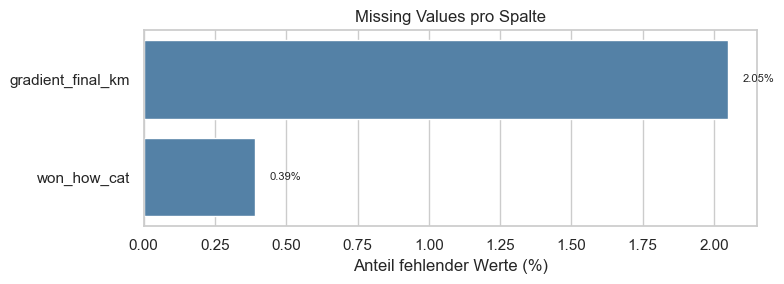

In [103]:
missing_all = pd.DataFrame(
    {
        "n_missing": df.isna().sum(),
        "missing_pct": (100 * df.isna().mean()).round(2),
    }
).sort_values(["n_missing", "missing_pct"], ascending=False)

missing_nonzero = missing_all.query("n_missing > 0")
print(f"Spalten mit echten Missing Values: {len(missing_nonzero)} von {df.shape[1]}")
display(missing_nonzero if not missing_nonzero.empty else missing_all.head(0))

if not missing_nonzero.empty:
    fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(missing_nonzero))))
    sns.barplot(x=missing_nonzero["missing_pct"], y=missing_nonzero.index, ax=ax, color="steelblue")
    ax.set_xlabel("Anteil fehlender Werte (%)")
    ax.set_ylabel("")
    ax.set_title("Missing Values pro Spalte")
    for i, v in enumerate(missing_nonzero["missing_pct"]):
        ax.text(v + 0.05, i, f"{v:.2f}%", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
else:
    print("Keine echten Missing Values im Datensatz.")

In [104]:
def placeholder_audit(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in frame.columns:
        s = frame[col]
        s_str = s.astype("string").str.strip()
        s_lower = s_str.str.lower()
        numeric_values = pd.to_numeric(s, errors="coerce")
        rows.append(
            {
                "column": col,
                "real_nan": int(s.isna().sum()),
                "inf": int(np.isinf(numeric_values.to_numpy(dtype=float, na_value=np.nan)).sum()),
                "zero": int((numeric_values == 0).sum()) if not pd.api.types.is_bool_dtype(s) else 0,
                "dash": int((s_str == "-").sum()),
                "question_mark": int((s_str == "?").sum()),
                "empty_string": int((s_str == "").sum()),
                "txt_nan": max(0, int((s_lower == "nan").sum()) - int(s.isna().sum())),
                "txt_null": int((s_lower == "null").sum()),
                "txt_none": int((s_lower == "none").sum()),
                "txt_unknown": int((s_lower == "unknown").sum()),
                "txt_undefined": int((s_lower == "undefined").sum()),
                "txt_not_found": int(s_lower.isin(["not found", "notfound"]).sum()),
                "txt_tbd": int((s_lower == "tbd").sum()),
            }
        )
    audit = pd.DataFrame(rows).set_index("column")
    audit["total_flags"] = audit.sum(axis=1)
    return audit.sort_values("total_flags", ascending=False)


audit_table = placeholder_audit(df)
display(audit_table.query("total_flags > 0"))

,real_nan,inf,zero,dash,question_mark,empty_string,txt_nan,txt_null,txt_none,txt_unknown,txt_undefined,txt_not_found,txt_tbd,total_flags
column,,,,,,,,,,,,,,
weather_precipitation_mean,0,0,100648,0,0,0,0,0,0,0,0,0,0,100648
weather_rain_prob_mean,0,0,100648,0,0,0,0,0,0,0,0,0,0,100648
gradient_final_km,4018,0,31087,0,0,0,0,0,0,0,0,0,0,35105
sprint,0,0,9411,0,0,0,0,0,0,0,0,0,0,9411
time_trial,0,0,5185,0,0,0,0,0,0,0,0,0,0,5185
hills,0,0,3725,0,0,0,0,0,0,0,0,0,0,3725
climber,0,0,2127,0,0,0,0,0,0,0,0,0,0,2127
won_how_cat,774,0,0,0,0,0,0,0,0,0,0,0,0,774
weather_temp_trend,0,0,691,0,0,0,0,0,0,0,0,0,0,691


## Zielvariable `rank`

`rank` ist die spätere Zielgröße. In der univariaten Analyse wird sie separat betrachtet, weil ihre Verteilung und eventuelle Missing Values für die Modellierung zentral sind.

Gesamtzeilen: 196,048
Fehlende ranks: 0 (0.00%)


,rank
count,196048.000000
mean,85.994001
std,50.461529
min,1.000000
5%,9.000000
25%,43.000000
50%,85.000000
75%,128.000000
95%,167.000000
max,206.000000


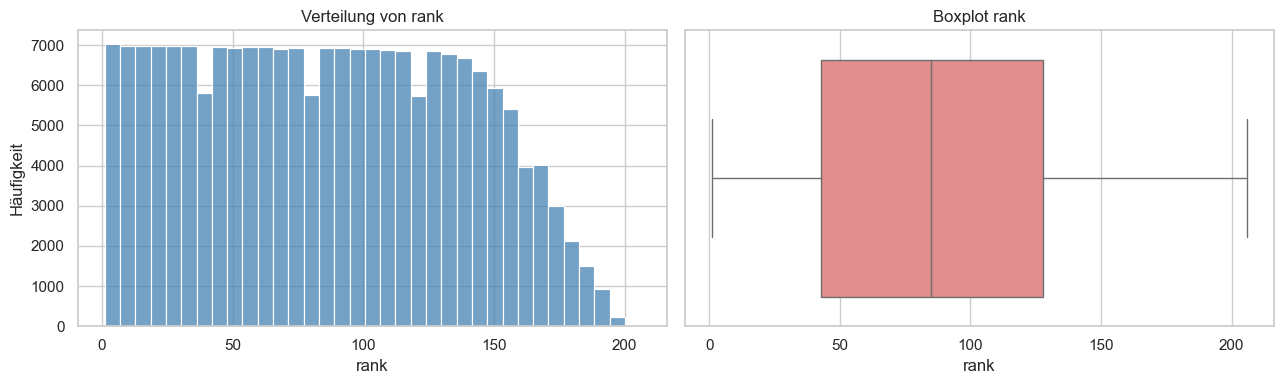

In [105]:
if "rank" in df.columns:
    rank_series = pd.to_numeric(df["rank"], errors="coerce")
    rank_clean = rank_series.dropna()
    print(f"Gesamtzeilen: {len(rank_series):,}")
    print(f"Fehlende ranks: {rank_series.isna().sum():,} ({100 * rank_series.isna().mean():.2f}%)")
    display(rank_clean.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame("rank"))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.histplot(rank_clean, bins=35, ax=axes[0], color="steelblue")
    axes[0].set_title("Verteilung von rank")
    axes[0].set_xlabel("rank")
    axes[0].set_ylabel("Häufigkeit")

    sns.boxplot(x=rank_clean, ax=axes[1], color="lightcoral")
    axes[1].set_title("Boxplot rank")
    axes[1].set_xlabel("rank")
    plt.tight_layout()
    plt.show()
    plt.close(fig)
else:
    print("rank ist im Datensatz nicht vorhanden.")

## Plot-Helfer

In [106]:
def plot_grid(
    frame: pd.DataFrame,
    cols: list[str],
    kind: str = "hist",
    ncols: int = 3,
    bins: int = 40,
    figsize_per_cell: tuple[float, float] = (4.5, 3.2),
    title: str | None = None,
    color: str = "steelblue",
) -> None:
    cols = [c for c in cols if c in frame.columns]
    if not cols:
        print("Keine darstellbaren Spalten.")
        return

    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_cell[0] * ncols, figsize_per_cell[1] * nrows),
        squeeze=False,
    )
    axes = axes.flatten()

    for ax, col in zip(axes, cols):
        s = pd.to_numeric(frame[col], errors="coerce").dropna()
        if s.empty:
            ax.set_visible(False)
            continue
        if kind == "hist":
            sns.histplot(s, bins=bins, ax=ax, color=color, kde=False)
            ax.set_ylabel("Häufigkeit")
            ax.set_xlabel(col)
        elif kind == "box":
            sns.boxplot(x=s, ax=ax, color=color)
            ax.set_xlabel(col)
        else:
            raise ValueError(f"Unbekannter Plot-Typ: {kind}")
        ax.set_title(col, fontsize=10)

    for ax in axes[len(cols):]:
        ax.set_visible(False)

    if title:
        fig.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

## Kontinuierliche Features: gruppierte Verteilungen

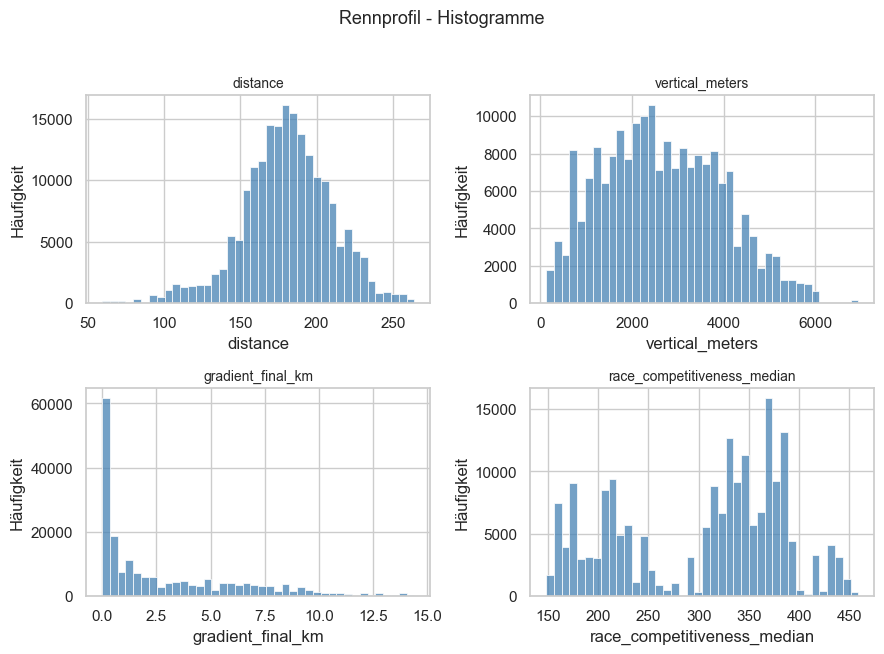

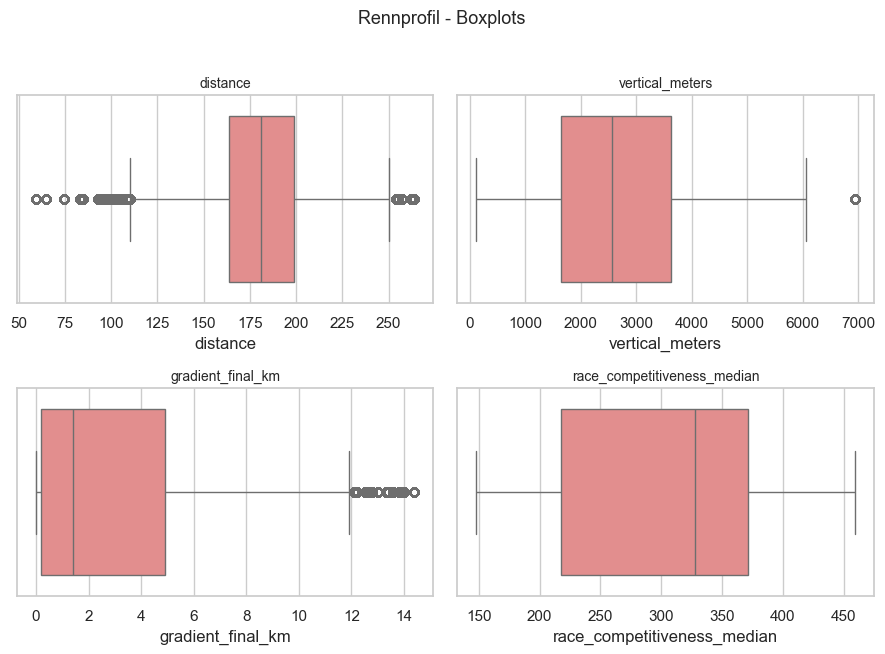

In [107]:
plot_grid(df, race_profile, kind="hist", ncols=2, title="Rennprofil - Histogramme")
plot_grid(df, race_profile, kind="box", ncols=2, color="lightcoral", title="Rennprofil - Boxplots")

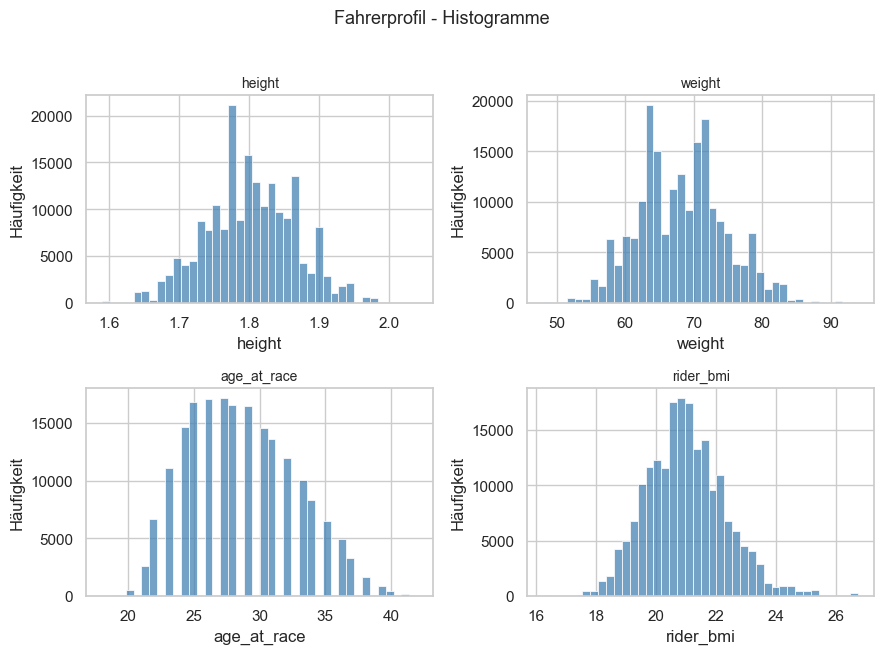

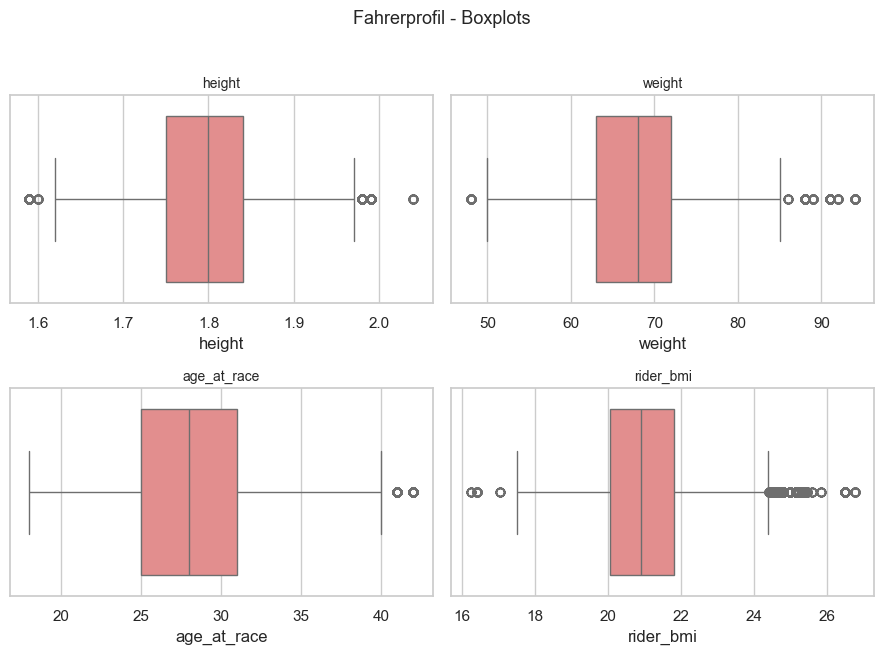

In [108]:
plot_grid(df, rider_profile, kind="hist", ncols=2, title="Fahrerprofil - Histogramme")
plot_grid(df, rider_profile, kind="box", ncols=2, color="lightcoral", title="Fahrerprofil - Boxplots")

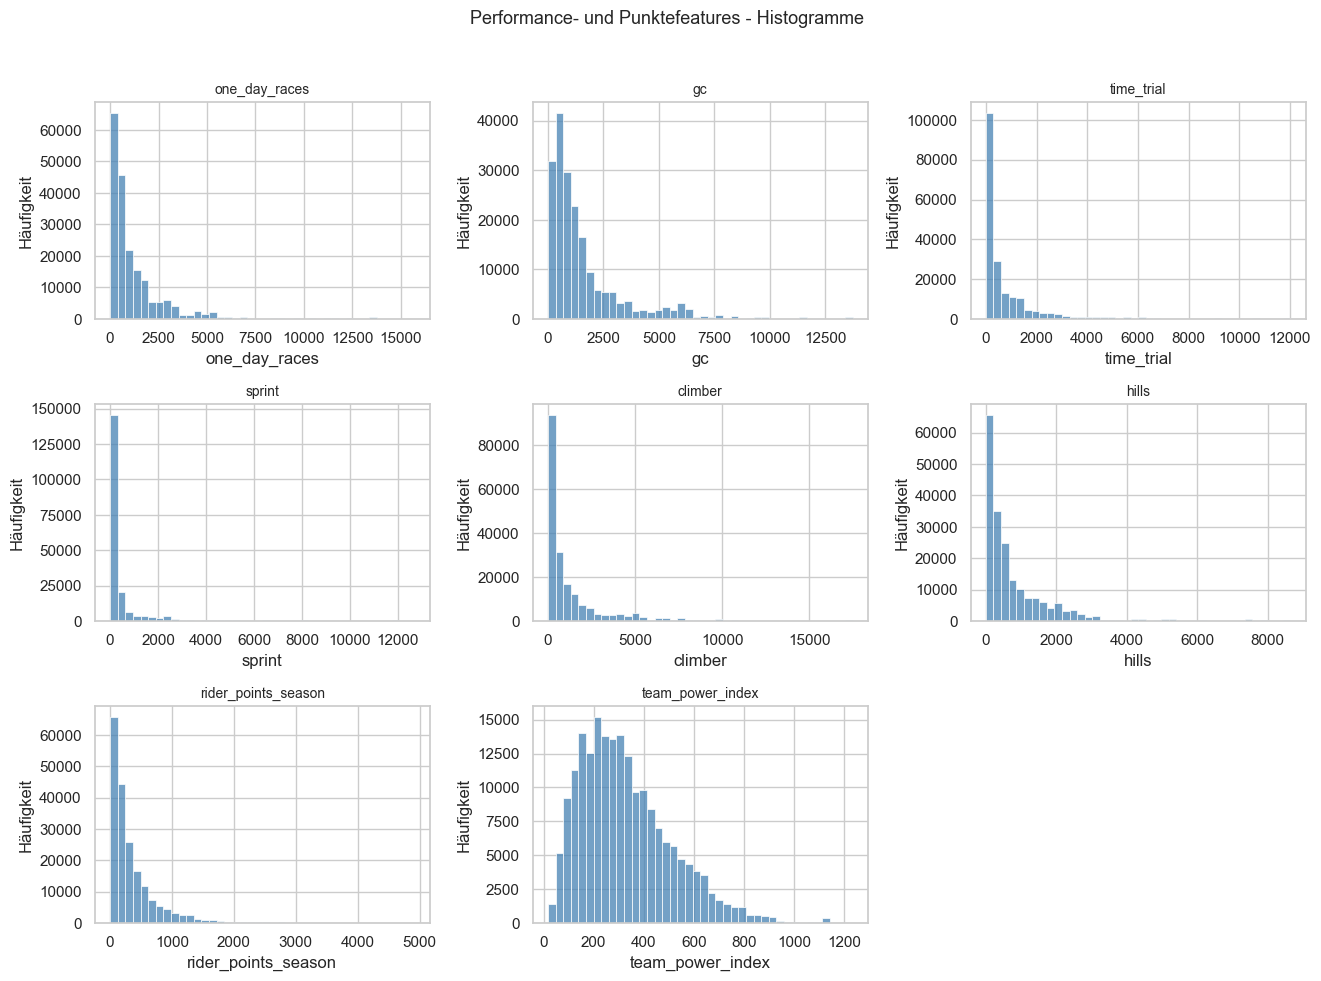

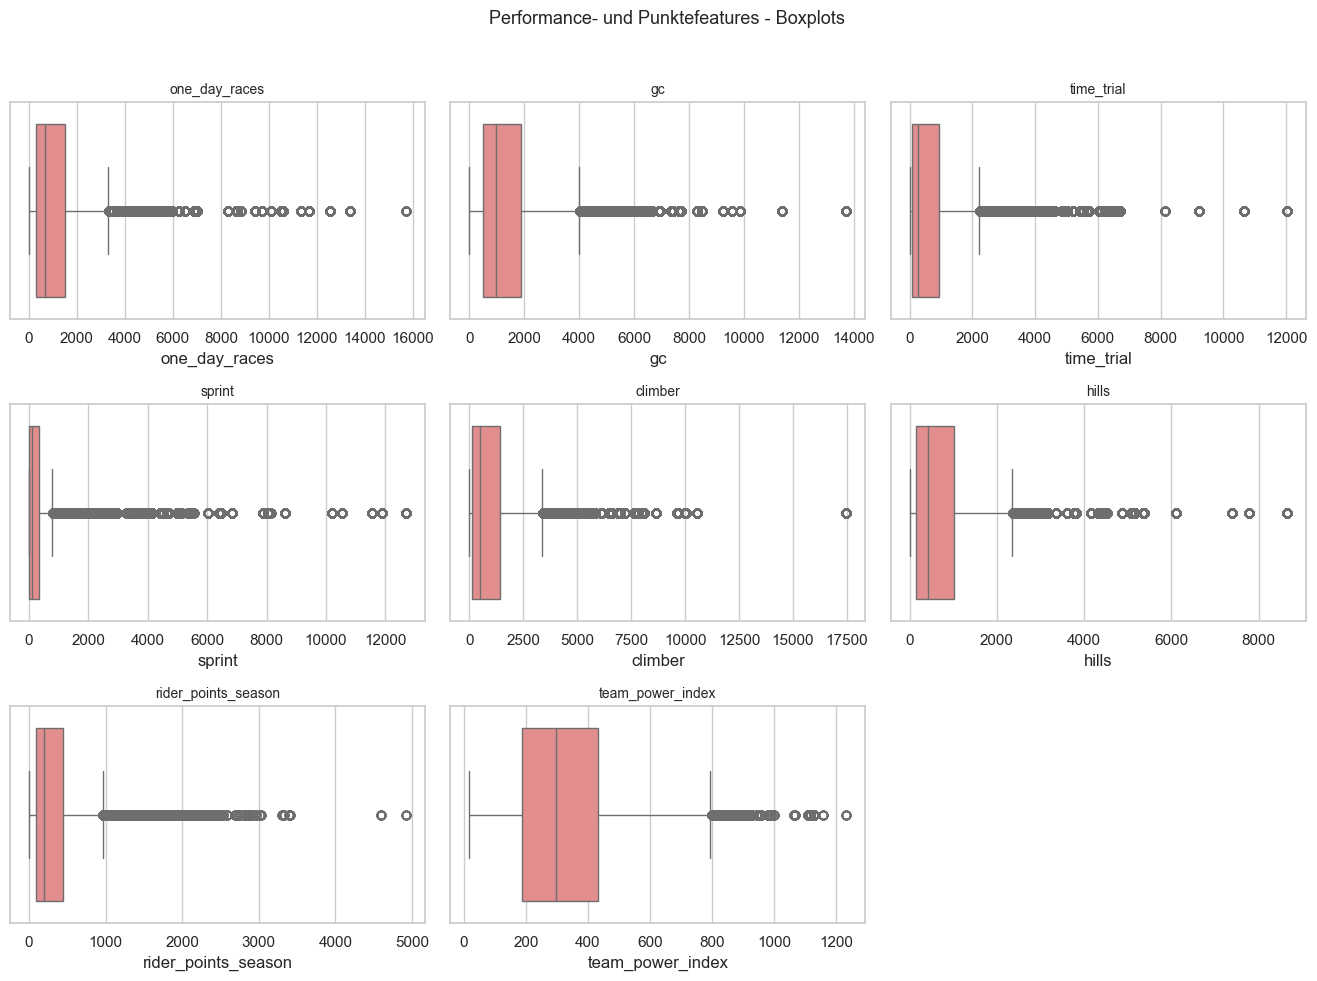

In [109]:
plot_grid(df, performance_scores, kind="hist", ncols=3, title="Performance- und Punktefeatures - Histogramme")
plot_grid(df, performance_scores, kind="box", ncols=3, color="lightcoral", title="Performance- und Punktefeatures - Boxplots")

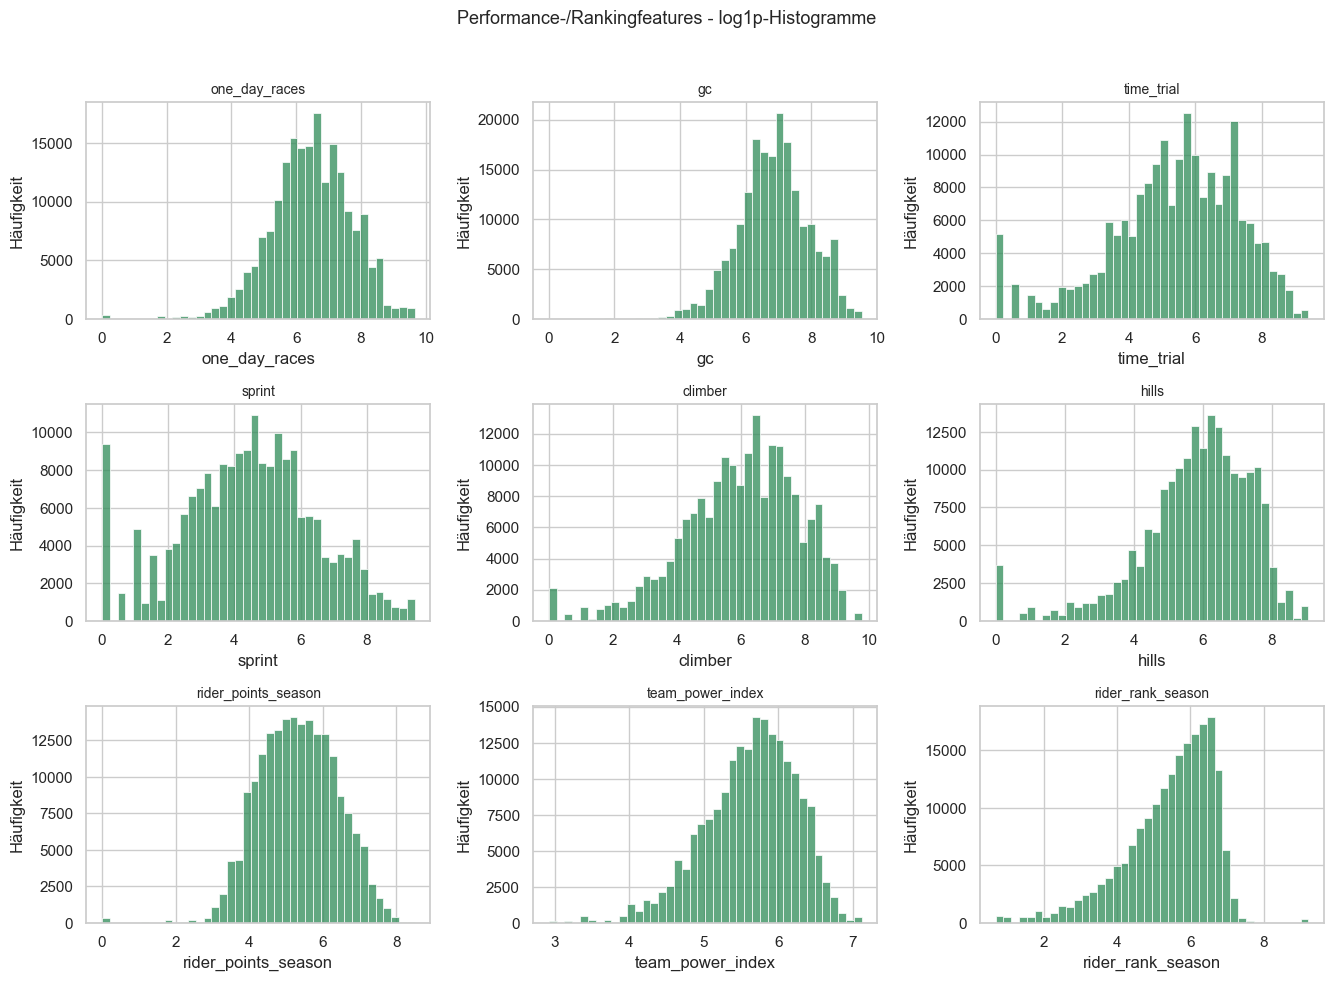

In [110]:
log_cols = _filter_existing([
    "one_day_races",
    "gc",
    "time_trial",
    "sprint",
    "climber",
    "hills",
    "rider_points_season",
    "team_power_index",
    "rider_rank_season",
])

log_df = df[log_cols].apply(lambda s: np.log1p(pd.to_numeric(s, errors="coerce").clip(lower=0)))
plot_grid(log_df, log_cols, kind="hist", ncols=3, color="seagreen", title="Performance-/Rankingfeatures - log1p-Histogramme")

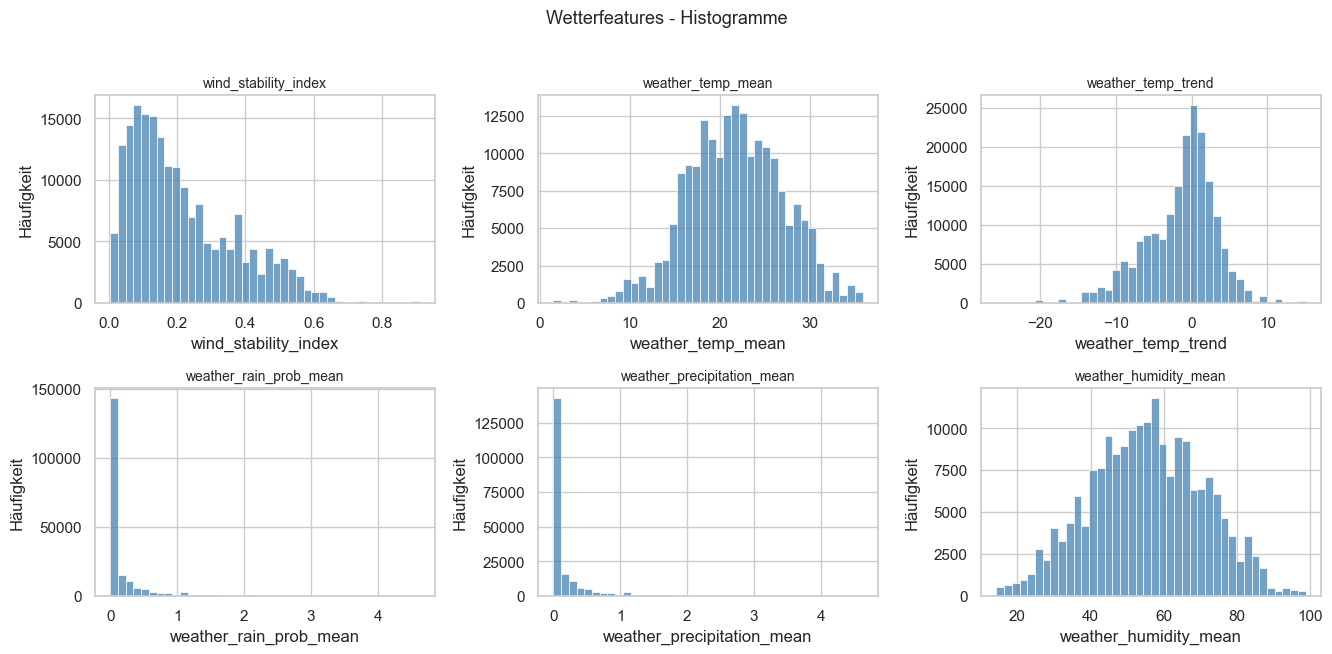

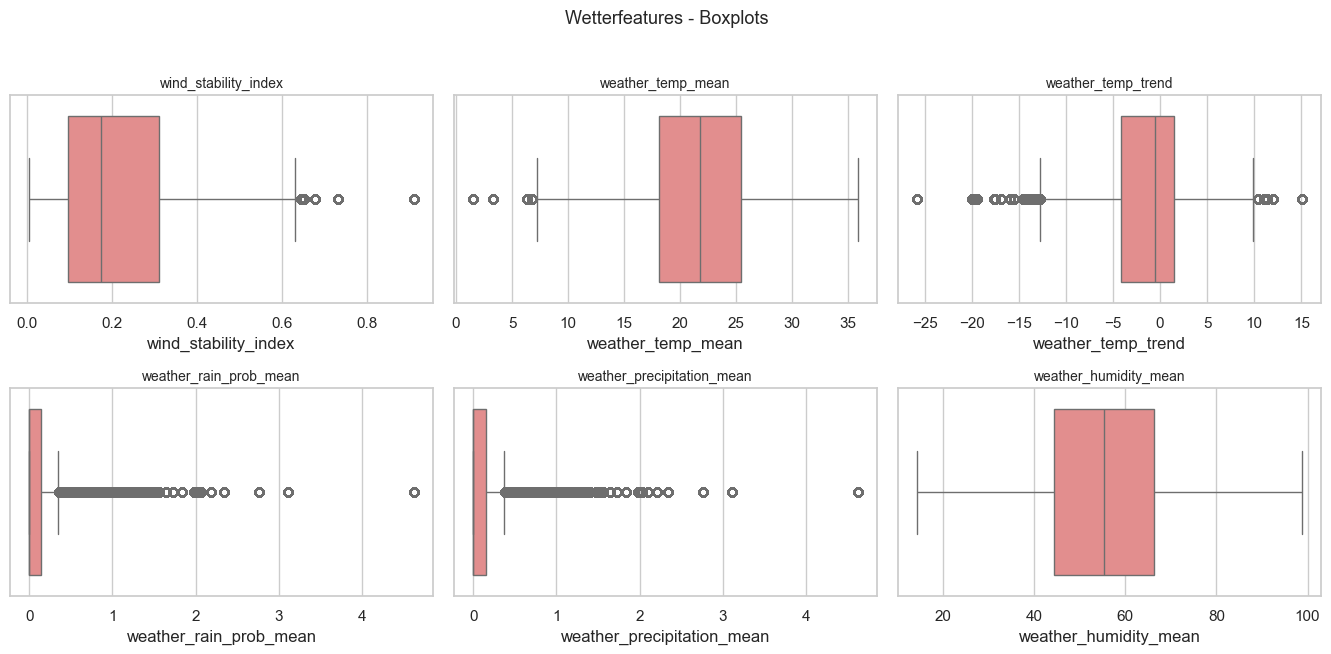

In [111]:
plot_grid(df, weather_features, kind="hist", ncols=3, title="Wetterfeatures - Histogramme")
plot_grid(df, weather_features, kind="box", ncols=3, color="lightcoral", title="Wetterfeatures - Boxplots")

## Ordinale und diskrete Features

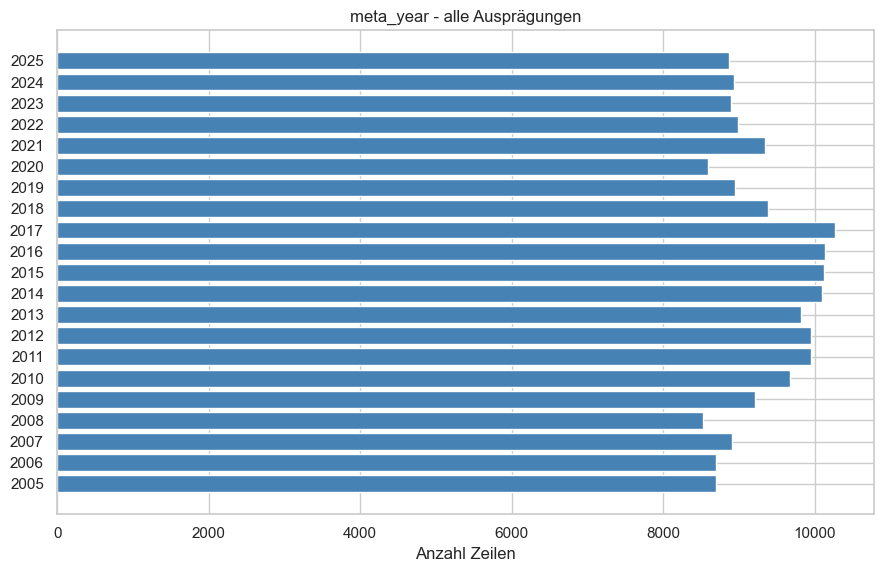

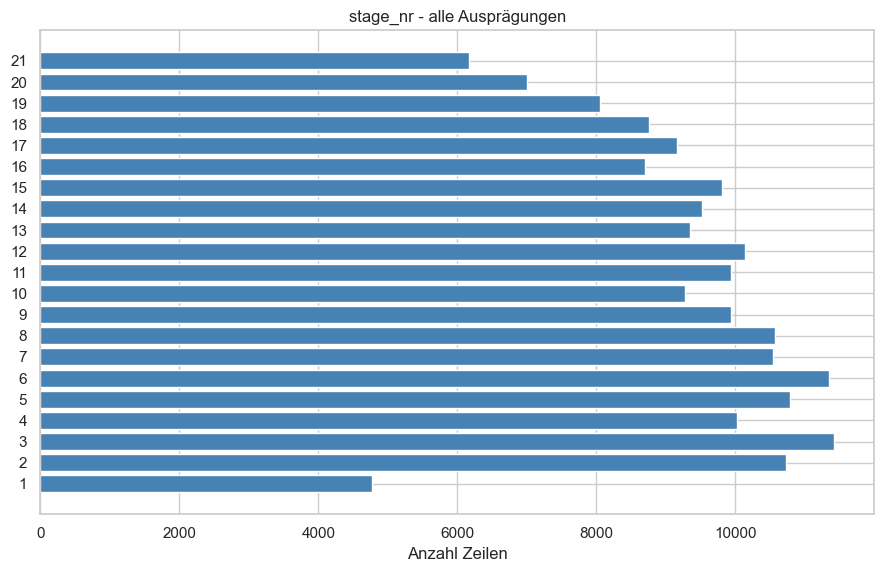

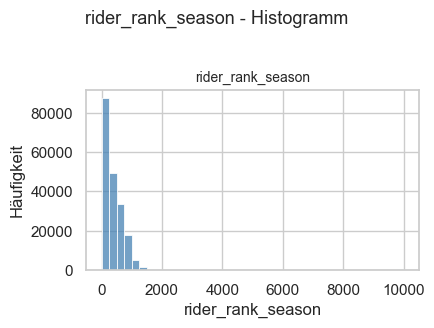

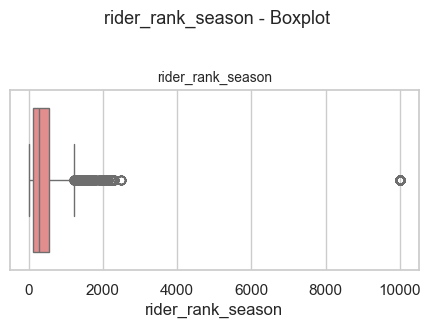

In [112]:
def plot_count_bars(frame: pd.DataFrame, cols: list[str], top_n: int = 30) -> None:
    for col in [c for c in cols if c in frame.columns]:
        s = frame[col].dropna()
        vc = s.value_counts().sort_index()
        if vc.shape[0] > top_n:
            vc = s.value_counts().head(top_n).sort_values()
            title_suffix = f"Top {top_n} nach Häufigkeit"
        else:
            title_suffix = "alle Ausprägungen"
        fig, ax = plt.subplots(figsize=(9, max(3, 0.28 * len(vc))))
        ax.barh(vc.index.astype(str), vc.values, color="steelblue")
        ax.set_title(f"{col} - {title_suffix}")
        ax.set_xlabel("Anzahl Zeilen")
        ax.set_ylabel("")
        plt.tight_layout()
        plt.show()
        plt.close(fig)


plot_count_bars(df, ["meta_year", "stage_nr"], top_n=35)
plot_grid(df, ["rider_rank_season"], kind="hist", ncols=1, title="rider_rank_season - Histogramm")
plot_grid(df, ["rider_rank_season"], kind="box", ncols=1, color="lightcoral", title="rider_rank_season - Boxplot")

## Kategoriale Features: Bar Charts

Für kategoriale Spalten werden die häufigsten Ausprägungen gezeigt. Bei hochkardinalen Spalten macht die Top-N-Darstellung die Verteilung lesbar, ohne tausende Kategorien zu plotten.


Niedrige Kardinalität: ['meta_race', 'meta_nationality', 'team_tier', 'won_how_cat']


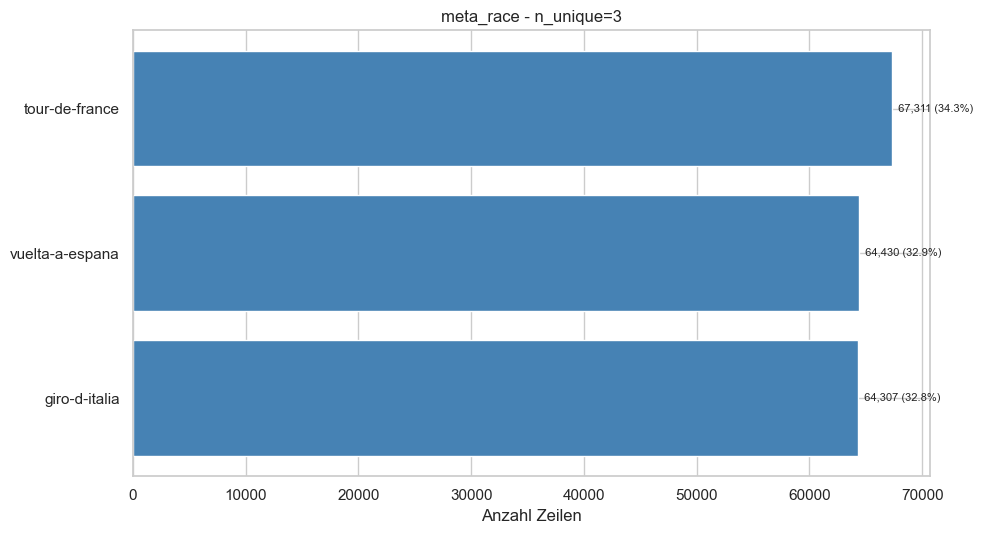

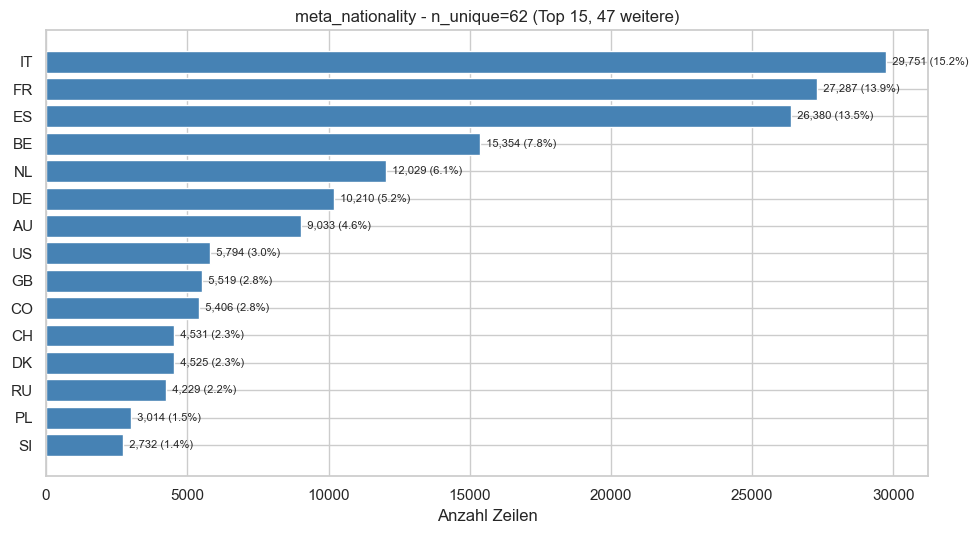

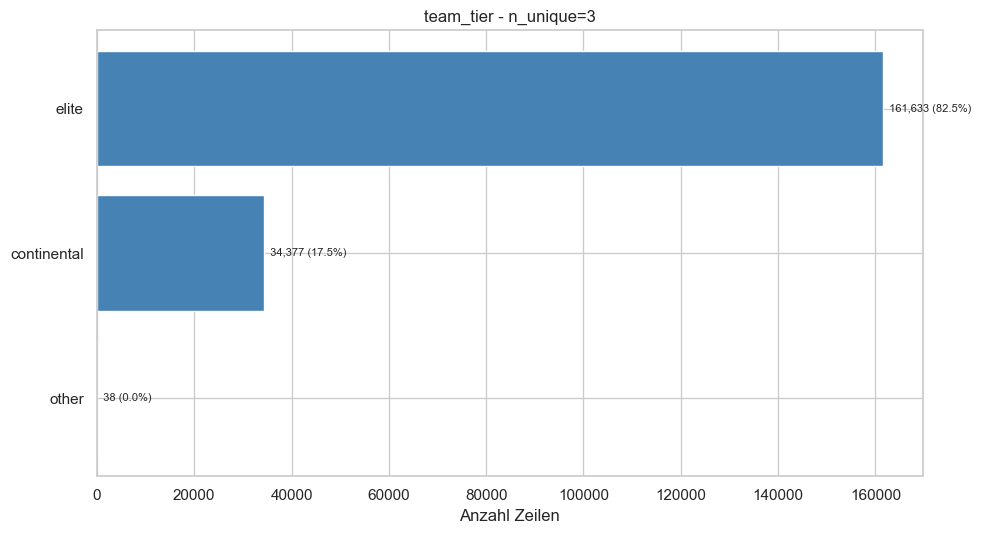

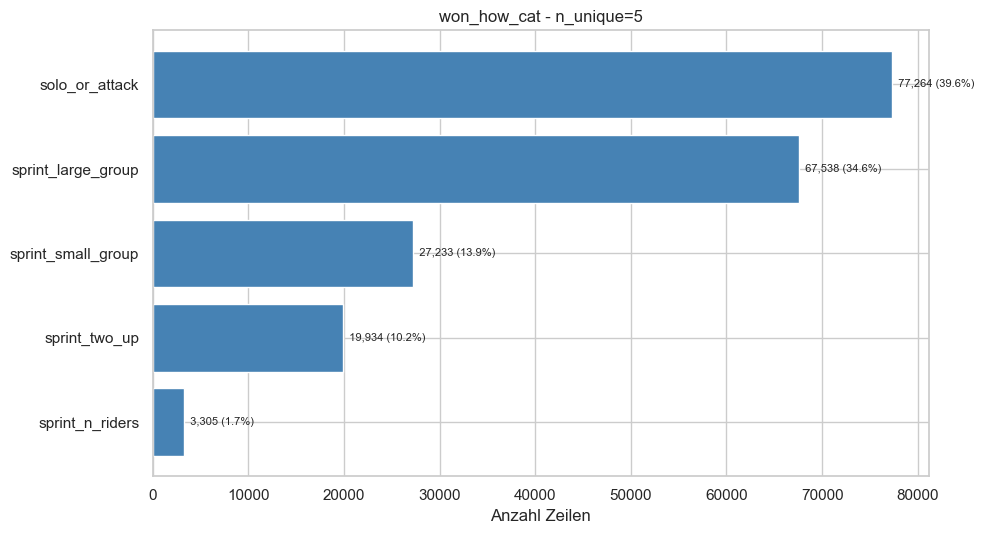


Hohe Kardinalität: ['meta_departure', 'meta_arrival', 'meta_current_team']


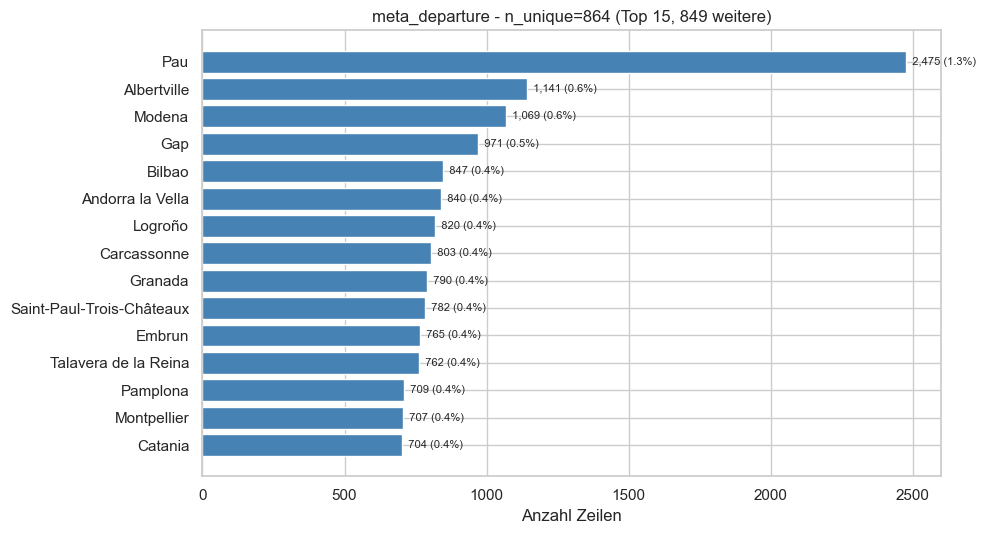

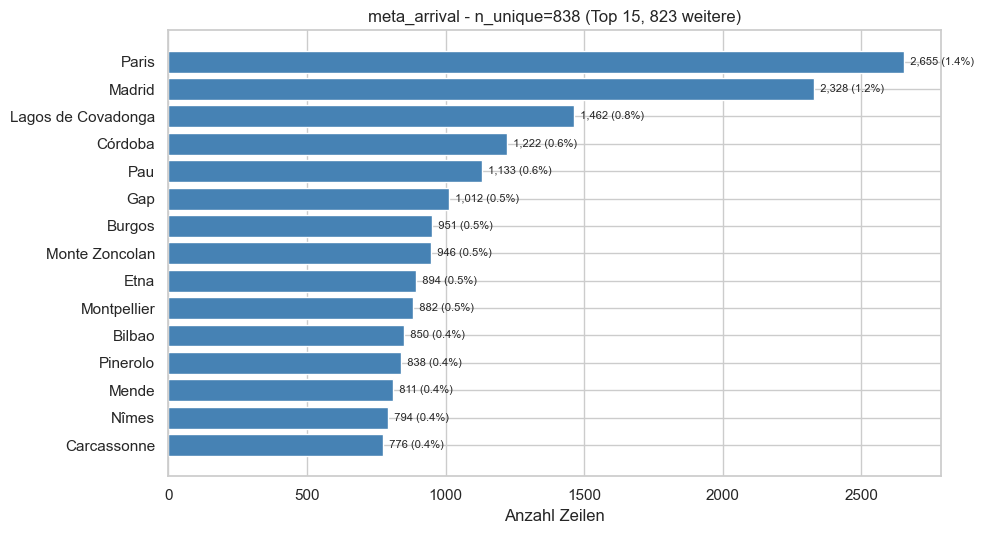

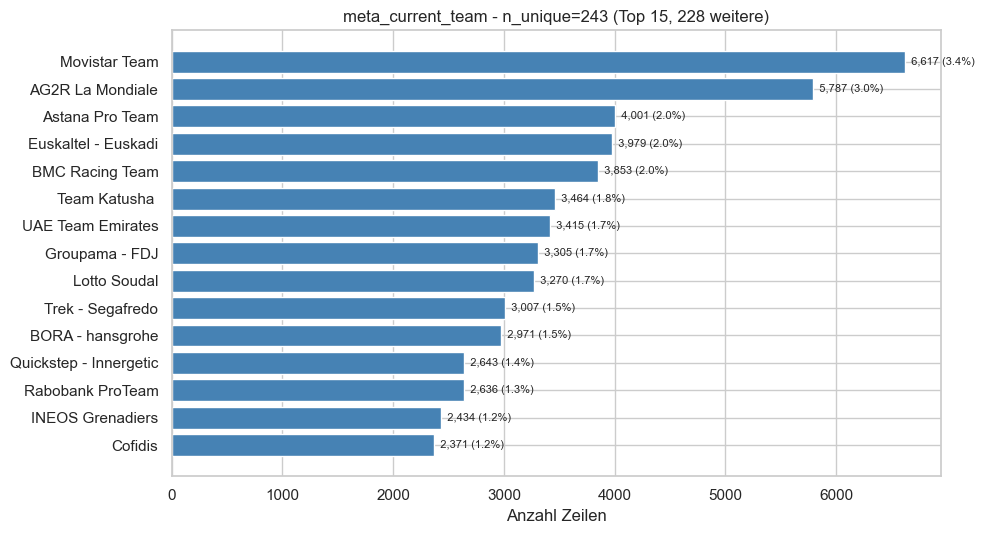

In [119]:
def categorical_barchart(series: pd.Series, top_n: int = 15, ax=None) -> None:
    s = series.dropna().astype(str)
    if s.empty:
        if ax is not None:
            ax.set_visible(False)
        return
    vc = s.value_counts()
    top = vc.head(top_n).sort_values()
    pct = (100 * top / len(s)).round(2)
    other_n = vc.shape[0] - top.shape[0]

    if ax is None:
        fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(top))))
    ax.barh(top.index, top.values, color="steelblue")
    for i, (cnt, p) in enumerate(zip(top.values, pct.values)):
        ax.text(cnt, i, f"  {cnt:,} ({p:.1f}%)", va="center", fontsize=8)
    title = f"{series.name} - n_unique={vc.shape[0]}"
    if other_n > 0:
        title += f" (Top {top_n}, {other_n} weitere)"
    ax.set_title(title)
    ax.set_xlabel("Anzahl Zeilen")
    ax.set_ylabel("")


for group_name, cols in [
    ("Niedrige Kardinalität", categorical_low),
    ("Hohe Kardinalität", categorical_high),
]:
    print(f"\n{group_name}: {cols}")
    for col in cols:
        fig, ax = plt.subplots(figsize=(10, 5.5))
        categorical_barchart(df[col], top_n=15, ax=ax)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

## Skewness und Kurtosis

Skewness beschreibt die Asymmetrie der Verteilung, Kurtosis die Stärke der Verteilungsschwänze. Besonders hohe absolute Skewness weist auf starke Rechtsschiefe oder Linksschiefe hin.

,skew,kurtosis
column,,
sprint,5.34,34.88
weather_rain_prob_mean,4.73,35.40
weather_precipitation_mean,4.68,34.57
time_trial,3.53,17.15
one_day_races,3.46,16.16
climber,3.16,14.47
hills,3.04,13.66
rider_points_season,2.79,11.92
gc,2.52,8.24


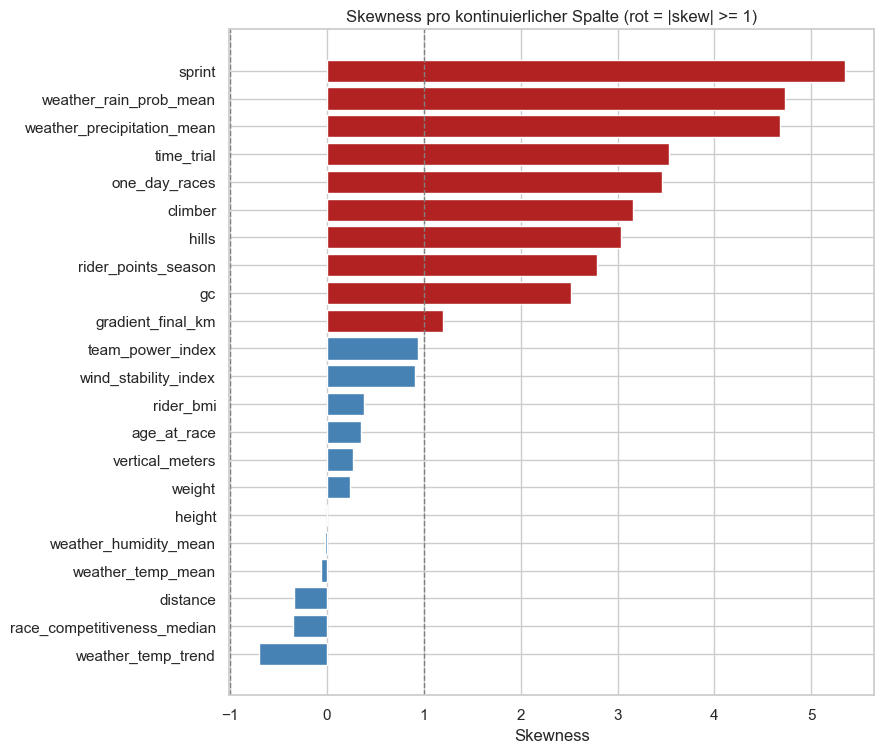

In [114]:
if not continuous_stats.empty:
    skew_table = (
        continuous_stats[["skew", "kurtosis"]]
        .assign(abs_skew=lambda x: x["skew"].abs())
        .sort_values("abs_skew", ascending=False)
        .drop(columns="abs_skew")
    )
    display(skew_table.round(2))

    sorted_skew = skew_table["skew"].sort_values()
    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(sorted_skew))))
    colors = ["firebrick" if abs(v) >= 1 else "steelblue" for v in sorted_skew]
    ax.barh(sorted_skew.index, sorted_skew.values, color=colors)
    ax.axvline(1, color="grey", linestyle="--", linewidth=1)
    ax.axvline(-1, color="grey", linestyle="--", linewidth=1)
    ax.set_xlabel("Skewness")
    ax.set_title("Skewness pro kontinuierlicher Spalte (rot = |skew| >= 1)")
    plt.tight_layout()
    plt.show()
    plt.close(fig)
else:
    skew_table = pd.DataFrame()
    print("Keine kontinuierlichen Spalten für Skewness/Kurtosis vorhanden.")

## Outlier Detection mit IQR-Methode

Die IQR-Regel markiert Werte außerhalb von `[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]` als statistische Ausreißer. Das ist eine Diagnose, keine automatische Löschregel.

In [115]:
def iqr_outliers(frame: pd.DataFrame, cols: list[str], k: float = 1.5) -> pd.DataFrame:
    rows = []
    for col in cols:
        s = pd.to_numeric(frame[col], errors="coerce").dropna().astype(float)
        if s.empty:
            continue
        q1, q3 = np.percentile(s, [25, 75])
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        outliers = s[(s < lower) | (s > upper)]
        rows.append(
            {
                "column": col,
                "n": int(s.shape[0]),
                "q1": q1,
                "q3": q3,
                "iqr": iqr,
                "lower_bound": lower,
                "upper_bound": upper,
                "min": s.min(),
                "max": s.max(),
                "n_outliers": int(outliers.shape[0]),
                "outlier_pct": round(100 * outliers.shape[0] / s.shape[0], 2),
            }
        )
    return (
        pd.DataFrame(rows)
        .set_index("column")
        .sort_values("outlier_pct", ascending=False)
        if rows
        else pd.DataFrame()
    )


outlier_table = iqr_outliers(df, continuous_features).round(3)
outlier_table

,n,q1,q3,iqr,lower_bound,upper_bound,min,max,n_outliers,outlier_pct
column,,,,,,,,,,
sprint,196048,21.000,333.000,312.000,-447.000,801.000,0.000,12697.000,26470,13.50
weather_rain_prob_mean,196048,0.000,0.140,0.140,-0.210,0.350,0.000,4.625,26064,13.29
weather_precipitation_mean,196048,0.000,0.150,0.150,-0.225,0.375,0.000,4.625,25346,12.93
climber,196048,128.000,1430.000,1302.000,-1825.000,3383.000,0.000,17476.000,22287,11.37
gc,196048,488.000,1893.000,1405.000,-1619.500,4000.500,0.000,13732.000,19250,9.82
time_trial,196048,71.000,929.000,858.000,-1216.000,2216.000,0.000,12022.000,18421,9.40
one_day_races,196048,293.000,1501.000,1208.000,-1519.000,3313.000,0.000,15708.000,16367,8.35
rider_points_season,196048,95.000,444.000,349.000,-428.500,967.500,0.000,4921.000,15081,7.69
hills,196048,145.000,1025.000,880.000,-1175.000,2345.000,0.000,8646.000,13813,7.05


Top-6 Spalten nach IQR-Outlier-Anteil:
['sprint', 'weather_rain_prob_mean', 'weather_precipitation_mean', 'climber', 'gc', 'time_trial']


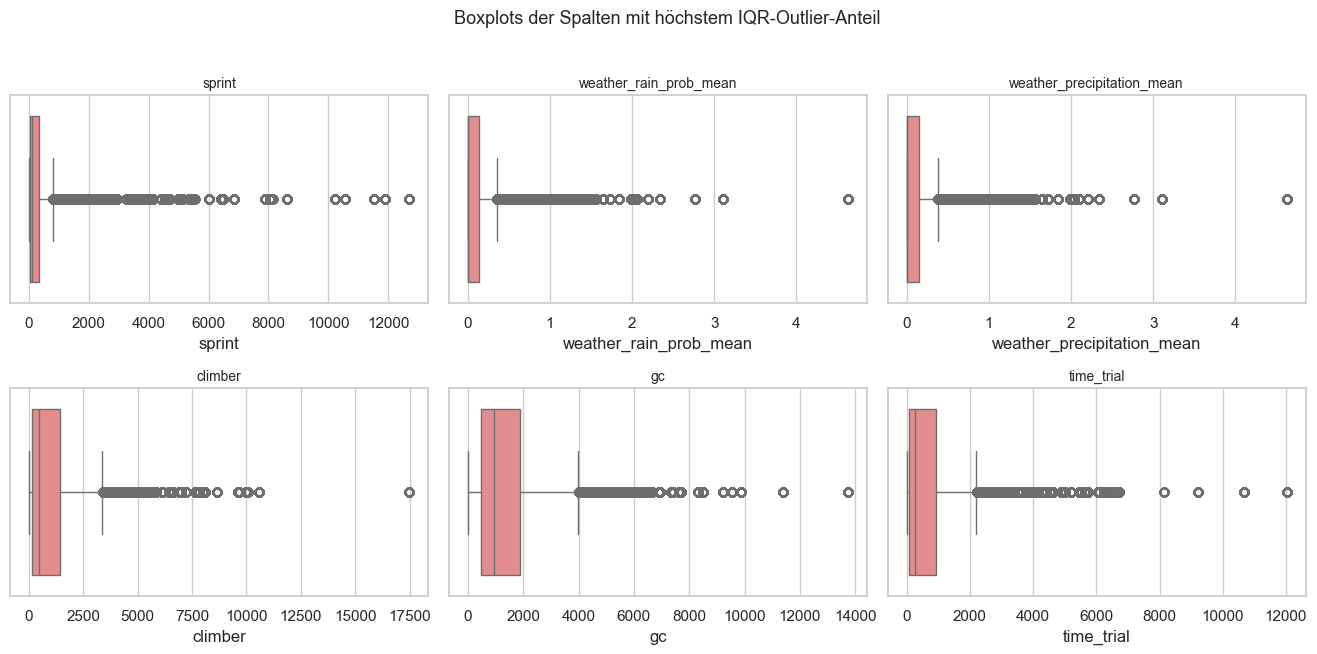

In [116]:
if not outlier_table.empty:
    top_outlier_cols = outlier_table.head(6).index.tolist()
    print("Top-6 Spalten nach IQR-Outlier-Anteil:")
    print(top_outlier_cols)
    plot_grid(
        df,
        top_outlier_cols,
        kind="box",
        ncols=3,
        color="lightcoral",
        title="Boxplots der Spalten mit höchstem IQR-Outlier-Anteil",
    )
else:
    print("Keine Outlier-Tabelle vorhanden.")

## Datengetriebene Kurzbefunde

In [118]:
findings = []
findings.append({"topic": "Datensatz", "finding": f"{df.shape[0]:,} Zeilen und {df.shape[1]} Spalten wurden geladen."})

if not missing_nonzero.empty:
    missing_desc = "; ".join(
        f"{idx}: {row.n_missing:,} ({row.missing_pct:.2f}%)"
        for idx, row in missing_nonzero.iterrows()
    )
else:
    missing_desc = "Keine echten Missing Values."
findings.append({"topic": "Missing Values", "finding": missing_desc})

if not skew_table.empty:
    top_skew_col = skew_table.index[0]
    findings.append(
        {
            "topic": "Skewness",
            "finding": f"Stärkste absolute Schiefe bei {top_skew_col} (skew={skew_table.loc[top_skew_col, 'skew']:.2f}).",
        }
    )

if not outlier_table.empty:
    top_outlier_col = outlier_table.index[0]
    findings.append(
        {
            "topic": "IQR-Outlier",
            "finding": f"Höchster IQR-Outlier-Anteil bei {top_outlier_col} ({outlier_table.loc[top_outlier_col, 'outlier_pct']:.2f}%).",
        }
    )

findings_df = pd.DataFrame(findings)
display(findings_df)

,topic,finding
0,Datensatz,"196,048 Zeilen und 42 Spalten wurden geladen."
1,Missing Values,"gradient_final_km: 4,018.0 (2.05%); won_how_ca..."
2,Skewness,Stärkste absolute Schiefe bei sprint (skew=5.34).
3,IQR-Outlier,Höchster IQR-Outlier-Anteil bei sprint (13.50%).
